### Imports

In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

from sklearn import linear_model
import lightgbm as lgbm

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import optuna 

### Read files & submission file for template

In [90]:
X_train = pd.read_csv('X_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv('y_train.csv',index_col='ROW_ID')
sample_submission = pd.read_csv('sample_submission.csv',index_col='ROW_ID')

In [91]:
X_train

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,0.002830,...,0.818730,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1
1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,-0.002160,...,-1.390336,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4
2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,-0.001488,...,0.961318,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1
3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,-0.005209,...,-0.483377,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2
4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,-0.003489,...,0.268005,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527068,DATE_2522,ALLOCATION_95,-0.000550,0.001751,0.002035,0.005264,0.003387,0.001825,-0.003642,0.001439,...,1.184249,1.154274,0.925998,1.154043,1.007770,0.801765,0.131619,NaN,0.000478,4
527069,DATE_2522,ALLOCATION_96,0.003501,-0.004601,-0.001739,-0.000052,0.003670,0.002518,0.006307,0.001633,...,0.673371,0.481303,0.702007,1.006299,1.256455,1.174986,1.539785,NaN,0.003128,3
527070,DATE_2522,ALLOCATION_97,0.005201,0.000580,-0.001607,-0.002955,0.000450,0.004747,0.004622,0.001928,...,0.775938,0.845494,0.799003,1.042934,1.260539,1.450301,1.492719,NaN,0.021932,3


### Features

In [92]:
RET_features = [f'RET_{i}' for i in range(1,21)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,21)]
TURNOVER_features = ['MEDIAN_DAILY_TURNOVER']

### Benchmarks

In [93]:
#calcul des bench pour la perf sur plusieurs fenetres et une perf journalière moyenne
for i in [3,5,10,15,20]:
    X_train[f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(axis=1) #pour faire la moyenne horizontale
    X_train[f'ALLOC_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[f'AVERAGE_PERF_{i}'].transform('mean') #pour faire la moyenne et l'applique à chaque TS
    
    X_test[f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i]].mean(axis=1)
    X_test[f'ALLOC_AVERAGE_PERF_{i}'] = X_test.groupby('TS')[f'AVERAGE_PERF_{i}'].transform('mean')
    
#calcul des bench pour la vol par allocation et par timestamp    

for i in [20]:
    X_train[f'STD_PERF_{i}']=X_train[RET_features[:i]].std(axis=1)
    X_train[f'ALLOC_STD_PERF_{i}']=X_train.groupby('TS')[f'STD_PERF_{i}'].transform('mean')
    
    X_test[f'STD_PERF_{i}']=X_test[RET_features[:i]].std(axis=1)
    X_test[f'ALLOC_STD_PERF_{i}']=X_test.groupby('TS')[f'STD_PERF_{i}'].transform('mean')

In [94]:
X_train

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,AVERAGE_PERF_5,ALLOC_AVERAGE_PERF_5,AVERAGE_PERF_10,ALLOC_AVERAGE_PERF_10,AVERAGE_PERF_15,ALLOC_AVERAGE_PERF_15,AVERAGE_PERF_20,ALLOC_AVERAGE_PERF_20,STD_PERF_20,ALLOC_STD_PERF_20
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,0.002830,...,-0.000555,-0.000702,-0.001426,-0.000484,-0.000657,-0.000409,-0.001856,-0.000393,0.005911,0.002714
1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,-0.002160,...,0.000305,-0.000702,0.001102,-0.000484,0.000649,-0.000409,0.000335,-0.000393,0.002591,0.002714
2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,-0.001488,...,-0.001992,-0.000702,-0.001914,-0.000484,-0.001678,-0.000409,-0.002040,-0.000393,0.005840,0.002714
3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,-0.005209,...,-0.001711,-0.000702,-0.000983,-0.000484,-0.001286,-0.000409,-0.001210,-0.000393,0.004174,0.002714
4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,-0.003489,...,-0.001153,-0.000702,0.001612,-0.000484,0.001409,-0.000409,0.000139,-0.000393,0.005615,0.002714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527068,DATE_2522,ALLOCATION_95,-0.000550,0.001751,0.002035,0.005264,0.003387,0.001825,-0.003642,0.001439,...,-0.000322,0.000101,-0.000278,-0.000127,0.000057,-0.000226,0.000637,-0.000189,0.002611,0.002423
527069,DATE_2522,ALLOCATION_96,0.003501,-0.004601,-0.001739,-0.000052,0.003670,0.002518,0.006307,0.001633,...,0.000841,0.000101,0.000034,-0.000127,0.000504,-0.000226,0.000417,-0.000189,0.003848,0.002423
527070,DATE_2522,ALLOCATION_97,0.005201,0.000580,-0.001607,-0.002955,0.000450,0.004747,0.004622,0.001928,...,0.000119,0.000101,-0.000711,-0.000127,0.000117,-0.000226,0.000171,-0.000189,0.003505,0.002423


### Features engineering

#### Momentum

In [95]:
#momentum court vs long : si positif, elle accélère momentum fort sinon s'essoufle
#momentum long
for i in [3,5]:
    X_train[f'MOMENTUM_{i}_20']=X_train[f'AVERAGE_PERF_{i}']-X_train['AVERAGE_PERF_20']
    X_test[f'MOMENTUM_{i}_20']=X_test[f'AVERAGE_PERF_{i}']-X_test['AVERAGE_PERF_20']
    
#momentum court
for i in [3]:
    X_train[f'MOMENTUM_{i}_10']=X_train[f'AVERAGE_PERF_{i}']-X_train['AVERAGE_PERF_10']
    X_test[f'MOMENTUM_{i}_10']=X_test[f'AVERAGE_PERF_{i}']-X_test['AVERAGE_PERF_10']



#### Mean-reversion

In [96]:
#si mean-reversion retour à la moyenne
#spike par rapport à la tendance longue et courte

for i in [3,5,20]: #ajout des fenêtres 3
    X_train[f'MEAN_REV_{i}']=X_train[RET_features[0]]-X_train[f'AVERAGE_PERF_{i}']
    X_test[f'MEAN_REV_{i}']=X_test[RET_features[0]]-X_test[f'AVERAGE_PERF_{i}']


#### Volume signé x Return

In [97]:
#le volume signe indique une pression d'achat ou de vente récente, on regarde sur 1,3 et 5j
for i in [0]:
    X_train[f'RET_x_VOL_{i+1}']=X_train[RET_features[i]]*X_train[SIGNED_VOLUME_features[i]]
    X_test[f'RET_x_VOL_{i+1}']=X_test[RET_features[i]]*X_test[SIGNED_VOLUME_features[i]]
    
for i in [3,5]:
    X_train[f'RET_x_VOL_{i}']=X_train[f'AVERAGE_PERF_{i}']*X_train[SIGNED_VOLUME_features[:i]].mean(axis=1) 
    X_test[f'RET_x_VOL_{i}']=X_test[f'AVERAGE_PERF_{i}']*X_test[SIGNED_VOLUME_features[:i]].mean(axis=1) 

#### NEW - Momentum très court terme (return 1 très important)

In [98]:
#interaction sur une même allocation
# return 1 par rapport VS 2,3
for i in [1,2]:
    X_train[f'ret_1_ret_{i+1}']=X_train[RET_features[0]]-X_train[RET_features[i]]
    X_test[f'ret_1_ret_{i+1}']=X_test[RET_features[0]]-X_test[RET_features[i]]
 
#return 2 vs 3   
for i in [2]:    
    X_train[f'ret_2_ret_{i+1}']=X_train[RET_features[1]]-X_train[RET_features[i]]
    X_test[f'ret_2_ret_{i+1}']=X_test[RET_features[1]]-X_test[RET_features[i]]
    

#### NEW Vérifie la corrélation entre GROUP 1 et les autres : leader

In [99]:
#groupby par timestamp pour voir la corrélation entre ret_1 du g1 et ret1 des autres ainsi que ret_2
# filtre sur G1
X_train_G1=X_train[X_train['GROUP']==1]
X_train_TS_G1 = X_train_G1.groupby('TS')[RET_features[0]].mean()

#filtre sur les autres G2, G3 et G4
X_train_G_others=X_train[X_train['GROUP']!=1]
X_train_TS_G_others = X_train_G_others.groupby('TS')[[RET_features[0],RET_features[1],RET_features[2]]].mean()

#calcul des corrélations : entre -1 et 1
corr_rets=[]
for i in [0,1,2]:
    corr_ret_local=X_train_TS_G1.corr(X_train_TS_G_others[RET_features[i]])
    corr_rets.append(corr_ret_local)
    print(f"La corrélation du GROUP 1 AVEC les autres GROUP par rapport au Return {i} : {float(corr_ret_local)}")
    
  


La corrélation du GROUP 1 AVEC les autres GROUP par rapport au Return 0 : 0.14879473046237401
La corrélation du GROUP 1 AVEC les autres GROUP par rapport au Return 1 : 0.04291369691651976
La corrélation du GROUP 1 AVEC les autres GROUP par rapport au Return 2 : 0.04414138289743724


#### Vérifie si le volume signé capture le bon signal (car RET_1_VOL_1 seul représenté)

In [100]:
#on calcule les ratio des returns et du volume 1 pour savoir si même distribution
ret_1_bin=(X_train[RET_features[0]]>0).astype(int).value_counts(normalize=True)
print(f"Proportion de return positifs : {ret_1_bin[1]}")

vol_1_bin=(X_train[SIGNED_VOLUME_features[0]]>0).astype(int).value_counts(normalize=True)
print(f"Proportion de volumes positifs : {vol_1_bin[1]}")

#on vérifie la propotion de positif du ret X volume signé
ret_x_vol_1_bin=(X_train['RET_x_VOL_1']>0).astype(int).value_counts(normalize=True)
print(f"Proportion de volumes X returns positifs : {ret_x_vol_1_bin[1]}")

#on vérifie pour G1 la distribution
X_train_G1=X_train[X_train['GROUP']==1]

ret_1_G1_bin=(X_train_G1[RET_features[0]]>0).astype(int).value_counts(normalize=True)
print(f"Proportion de return positifs pour G1: {ret_1_G1_bin[1]}")

vol_1_G1_bin=(X_train_G1[SIGNED_VOLUME_features[0]]>0).astype(int).value_counts(normalize=True)
print(f"Proportion de volumes positifs pour G1: {vol_1_G1_bin[1]}")

Proportion de return positifs : 0.511722285148357
Proportion de volumes positifs : 0.16171384229509006
Proportion de volumes X returns positifs : 0.1352602011486075
Proportion de return positifs pour G1: 0.5072277128880902
Proportion de volumes positifs pour G1: 0.16509933113706698


#### Interaction avec GROUP

In [101]:
#pour chaque groupe on note le momentum à court terme, mean rev long terme, volume signé x Return et la perf sur 3 J de l'allocation
for g in [1, 2, 3, 4]:
    #TRAIN
    mask = (X_train['GROUP'] == g) #mask booléen
    X_train[f'MOMENTUM_3_20_G{g}'] = X_train['MOMENTUM_3_20'] * mask
    X_train[f'MEAN_REV_20_G{g}'] = X_train['MEAN_REV_20'] * mask
    X_train[f'RET_x_VOL_1_G{g}'] = X_train['RET_x_VOL_1'] * mask
    X_train[f'AVERAGE_PERF_3_G{g}'] = X_train['AVERAGE_PERF_3'] * mask
    
    #nouvelle features
    X_train[f'MEAN_REV_3_G{g}'] = X_train['MEAN_REV_3'] * mask
    
    #NEW momentum court termes
    X_train[f'ret_1_ret_2_G{g}'] = X_train['ret_1_ret_2'] * mask
    X_train[f'ret_1_ret_3_G{g}'] = X_train['ret_1_ret_3'] * mask
    X_train[f'ret_2_ret_3_G{g}'] = X_train['ret_2_ret_3'] * mask
    
    #TEST
    mask = (X_test['GROUP'] == g)
    X_test[f'MOMENTUM_3_20_G{g}'] = X_test['MOMENTUM_3_20'] * mask
    X_test[f'MEAN_REV_20_G{g}'] = X_test['MEAN_REV_20'] * mask
    X_test[f'RET_x_VOL_1_G{g}'] = X_test['RET_x_VOL_1'] * mask
    X_test[f'AVERAGE_PERF_3_G{g}'] = X_test['AVERAGE_PERF_3'] * mask
    
    #nouvelle features
    X_test[f'MEAN_REV_3_G{g}'] = X_test['MEAN_REV_3'] * mask
    
    #NEW momentum court termes
    X_test[f'ret_1_ret_2_G{g}'] = X_test['ret_1_ret_2'] * mask
    X_test[f'ret_1_ret_3_G{g}'] = X_test['ret_1_ret_3'] * mask
    X_test[f'ret_2_ret_3_G{g}'] = X_test['ret_2_ret_3'] * mask

#### Construction des features

In [102]:
features_raw=RET_features + SIGNED_VOLUME_features + TURNOVER_features

features_bench=[f'AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features_bench=features_bench + [f'ALLOC_AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features_bench=features_bench + [f'STD_PERF_{i}' for i in [20]]
features_bench=features_bench + [f'ALLOC_STD_PERF_{i}' for i in [20]]

#1) on retire les momentum qui n'ont pas d'impact
# features_eng=[f'MOMENTUM_{i}_20' for i in [3,5]] 
# features_eng=features_eng + [f'MOMENTUM_3_20_G{g}' for g in [1,2,3,4]] 

features_eng= [f'MOMENTUM_{i}_10' for i in [3]]
features_eng=features_eng + [f'RET_x_VOL_{i+1}' for i in [0]] 
features_eng=features_eng + [f'RET_x_VOL_{i}' for i in [3,5]] 

#NEW on ajoute les fenetres 3
features_eng=features_eng + [f'MEAN_REV_{i}' for i in [3,5,20]] 

features_eng=features_eng + [f'MEAN_REV_20_G{g}' for g in [1,2,3,4]] 
features_eng=features_eng + [f'RET_x_VOL_1_G{g}' for g in [1,2,3,4]] 
features_eng=features_eng + [f'AVERAGE_PERF_3_G{g}' for g in [1,2,3,4]] 
#ajout des nouvelles features
features_eng=features_eng + [f'MEAN_REV_3_G{g}' for g in [1,2,3,4]]


features=features_raw+features_bench+features_eng


#### Features du modèle Ridge

In [103]:
features_ridge=features_raw+features_bench

#### Modèle Ridge - baseline

In [104]:
#fitting et test du modèle ridge
new_ridge = linear_model.Ridge(alpha=1)

new_ridge.fit(X_train[features].to_numpy(na_value=0),y_train.to_numpy(na_value=0))

preds_ridge = pd.DataFrame(new_ridge.predict(X_test[features].fillna(0).to_numpy(na_value=0)), index = sample_submission.index,columns=['target'])

#### Features du modèle LGBM

In [105]:
#attribution des features
features_lgbm = features 

#### Optuna : trouver la meilleur combinaison de paramètre

In [106]:
#création de la fonction objective qui va tester les multiples combinaisons
def objective(trial):
    # 1. Optuna suggère des valeurs
    max_depth = trial.suggest_int('max_depth', 2, 6)
    learning_rate= trial.suggest_float('learning_rate', 1e-3, 1e-1, log=True) # on met log pour échantilonner uniformément
    NUM_BOOST_ROUND_optuna = trial.suggest_int('NUM_BOOST_ROUND', 300, 1500)
    
    # 2. On entraîne le modèle avec ces valeurs
    #on équilibre avec un grand nombre d'arbre et peu de profondeur pour éviter l'overfit, et on adaptera selon le résultat Kfold
    #hyperparamètres
    lgbm_params = {
                    "objective": "mse", #métrique à mesurer
                    "metric": "mse",
                    "num_threads": 10, #nb de thres CPU dépend du nb de coeur
                    "seed": 42,
                    "verbosity": -1, #pour retirer les lignes de log
                    'learning_rate': learning_rate, #vitesse à laquelle le modèle apprend
                    'max_depth': max_depth, #profondeur de l'arbre
    }
    NUM_BOOST_ROUND = NUM_BOOST_ROUND_optuna #1000 arbres

    #liste des dates
    train_dates = X_train['TS'].unique()
    test_dates = X_test['TS'].unique()

    n_splits = 4 # -on réduit à 4 pour réduire le temps de la fonction objective
    scores_lgbm = []
    models_lgbm = []
    
    #on peut laisser shuffle True car les dates sont anonymisées 
    splits = KFold(n_splits=n_splits, random_state=0,
                shuffle=True,).split(train_dates)

    print(splits)

    #on fait des splits par dates : met des dates en 8 groupes
    for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
        #on récupère les dates du fold à partir des indices
        local_train_dates = train_dates[local_train_dates_ids]
        local_test_dates = train_dates[local_test_dates_ids]
        
        #on reporte les indices train et test sur le set train
        local_train_ids = X_train['TS'].isin(local_train_dates)
        local_test_ids = X_train['TS'].isin(local_test_dates) #on fait sur X_train car on veut simuler le test et estimer la perfomance avant de soumettre sur le vrai set de X_test csv
        
        #on filtre sur nos set de train et set les dates
        X_local_train = X_train.loc[local_train_ids,[x for x in features_lgbm ]] 
        y_local_train = y_train.loc[local_train_ids,'target']

        X_local_test = X_train.loc[local_test_ids,[x for x in features_lgbm ]] 
        y_local_test = y_train.loc[local_test_ids,'target']
        
        #on fait une copie du dataset
        X_tr = X_local_train
        y_tr= y_local_train
        X_val= X_local_test
        y_val= y_local_test
        
        #on transfprme la donée fit du modèle
        train_data = lgbm.Dataset(X_tr, label=y_tr.values) 
        model_lgbm = lgbm.train(lgbm_params, train_data,num_boost_round=NUM_BOOST_ROUND)
        
        #prediction
        y_local_pred = model_lgbm.predict(X_val.values, num_threads = lgbm_params['num_threads'])
        
        #on stock les modèles dans l'ensemble afin de réduire la variance et améliorer la robustesse en faisant la moyenne
        models_lgbm.append(model_lgbm)
        
        #on veut des valeurs booléennes 0 ou 1, donc on veut que des positfs
        score_lgbm = accuracy_score((y_local_test>0).astype(int),
                    (y_local_pred>0).astype(int))
        scores_lgbm.append(score_lgbm)
        print(f"Fold {i+1} - Accuracy: {score_lgbm* 100:.2f}%")
        
    #calcul de la moyenne  
    mean = np.mean(scores_lgbm)*100
    
    
    # 3. On retourne le score
    return mean


In [107]:
#on lance optuna 
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=20)


#### Modèle LightGBM + cross-validation

In [108]:
#on équilibre avec un grand nombre d'arbre et peu de profondeur pour éviter l'overfit, et on adaptera selon le résultat Kfold
#hyperparamètres après optimisation par optuna

# max_depth_optuna =  5 
# learning_rate_optuna=  0.003391053138789811
# NUM_BOOST_ROUND_optuna= 729

#hyperparamètre du meilleur modèle
lgbm_params = {
                "objective": "mse", #métrique à mesurer
                "metric": "mse",
                "num_threads": 10, #nb de thres CPU dépend du nb de coeur
                "seed": 42,
                "verbosity": -1, #pour retirer les lignes de log
                'learning_rate': 1e-2, #vitesse à laquelle le modèle apprend
                'max_depth': 3, #profondeur de l'arbre
}
NUM_BOOST_ROUND = 500 # arbres

#liste des dates
train_dates = X_train['TS'].unique()
test_dates = X_test['TS'].unique()

n_splits = 8 
scores_lgbm = []
models_lgbm = []
 
#on peut laisser shuffle True car les dates sont anonymisées 
splits = KFold(n_splits=n_splits, random_state=0,
               shuffle=True,).split(train_dates)

print(splits)

#on fait des splits par dates : met des dates en 8 groupes
for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
    #on récupère les dates du fold à partir des indices
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]
    
    #on reporte les indices train et test sur le set train
    local_train_ids = X_train['TS'].isin(local_train_dates)
    local_test_ids = X_train['TS'].isin(local_test_dates) #on fait sur X_train car on veut simuler le test et estimer la perfomance avant de soumettre sur le vrai set de X_test csv
    
    #on filtre sur nos set de train et set les dates
    X_local_train = X_train.loc[local_train_ids,[x for x in features_lgbm ]] 
    y_local_train = y_train.loc[local_train_ids,'target']

    X_local_test = X_train.loc[local_test_ids,[x for x in features_lgbm ]] 
    y_local_test = y_train.loc[local_test_ids,'target']
    
    #on fait une copie du dataset
    X_tr = X_local_train
    y_tr= y_local_train
    X_val= X_local_test
    y_val= y_local_test
    
    #on transfprme la donée fit du modèle
    train_data = lgbm.Dataset(X_tr, label=y_tr.values) 
    model_lgbm = lgbm.train(lgbm_params, train_data,num_boost_round=NUM_BOOST_ROUND)
    
    #prediction
    y_local_pred = model_lgbm.predict(X_val.values, num_threads = lgbm_params['num_threads'])
    
    #on stock les modèles dans l'ensemble afin de réduire la variance et améliorer la robustesse en faisant la moyenne
    models_lgbm.append(model_lgbm)
    
    #on veut des valeurs booléennes 0 ou 1, donc on veut que des positfs
    score_lgbm = accuracy_score((y_local_test>0).astype(int),
                (y_local_pred>0).astype(int))
    scores_lgbm.append(score_lgbm)
    print(f"Fold {i+1} - Accuracy: {score_lgbm* 100:.2f}%")
    
#calcul de la moyenne et des écart-type    
mean = np.mean(scores_lgbm)*100
std = np.std(scores_lgbm)*100 #pour évaluer l'overfitting

#intervalle de confiance
u = (mean + std)
l = (mean - std)
print(f'Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})')
    

<generator object _BaseKFold.split at 0x121f9ef80>
Fold 1 - Accuracy: 52.14%
Fold 2 - Accuracy: 52.41%
Fold 3 - Accuracy: 52.18%
Fold 4 - Accuracy: 52.49%
Fold 5 - Accuracy: 52.09%
Fold 6 - Accuracy: 52.56%
Fold 7 - Accuracy: 52.25%
Fold 8 - Accuracy: 51.97%
Accuracy: 52.26% [52.07 ; 52.45] (+- 0.19)


#### Prédiction sur le vrai set X_test avec cross-validation

In [109]:
#on fait prédire l'ensemble sur le vrai set de X_test pour avoir la vraie accuracy
X_test=X_test[features_lgbm].copy()
y_predicts = []

#prédiction de X_test avec les 8 modèles
for model in models_lgbm:
    y_pred=model.predict(X_test.values, num_threads = lgbm_params['num_threads'])
    y_predicts.append(y_pred)

#moyenne des prédictions 8 modèles pour chaque ligne
avg_predict=np.mean(y_predicts,axis=0)

# on veut la prédiction binaire
avg_predict_bin=(avg_predict>0).astype(int)

df_avg_predict_bin=pd.DataFrame(avg_predict_bin, index=sample_submission.index,columns=['prediction']) 

#répartition des valeurs
df_avg_predict_bin.value_counts()

prediction
1             18880
0             12990
Name: count, dtype: int64

#### Soumission du fichier

In [111]:
df_avg_predict_bin.to_csv('preds_lgbm_tuned.csv')

#### Plot des résultats

##### Plot des features importance

<Axes: >

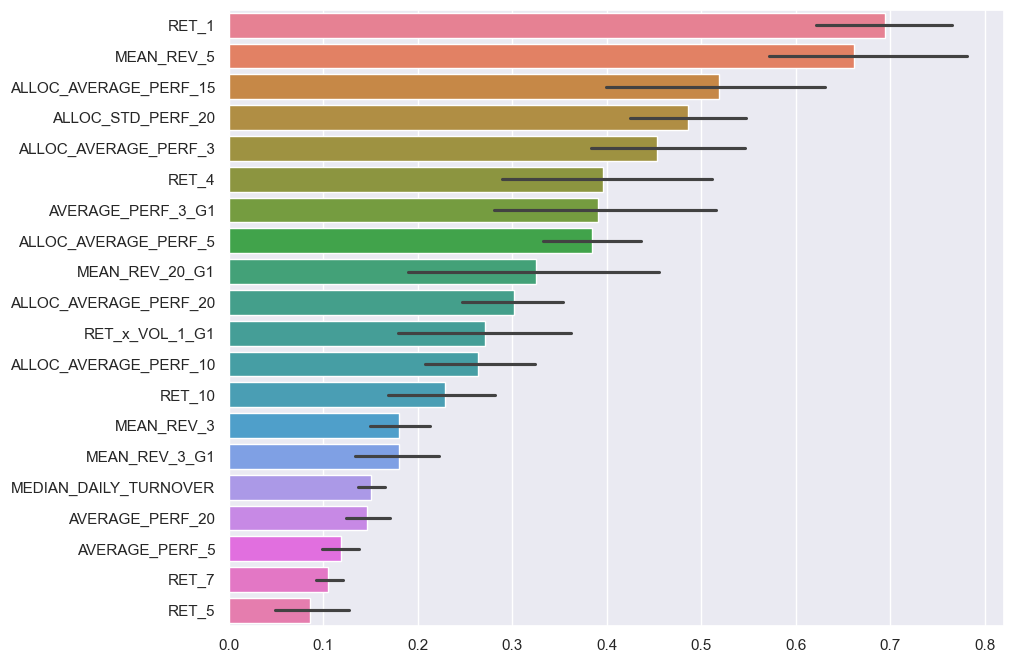

In [110]:
#on récupère les features importances
feature_importances = pd.DataFrame([model_lgbm.feature_importance(importance_type='gain') for model_lgbm in models_lgbm], columns=features_lgbm)
#on fait la moyenne sur les 20 plus importantes

feature_importances = feature_importances.loc[:,feature_importances.mean(axis=0).sort_values(ascending=False).index[:20]]

#plot avec les barres d'erreurs qui mesurent la variance entre les 8 folds
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)

##### Scores par fold du KFold du meilleur modèle

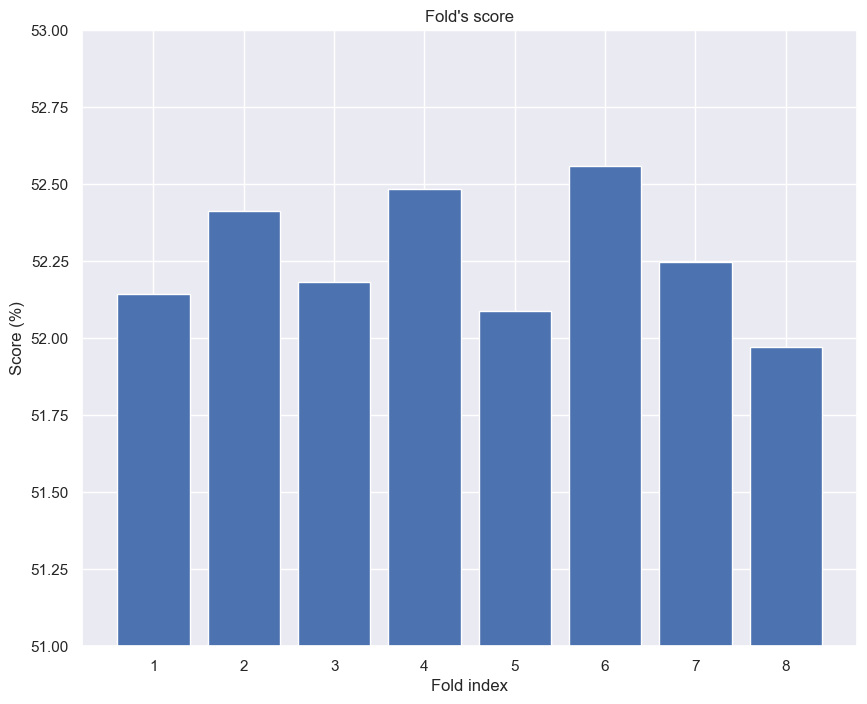

In [128]:
plt.figure(figsize=(10, 8))
plt.bar(range(1,9),[s*100 for s in scores_lgbm])
plt.ylim(51, 53)
plt.xlabel('Fold index')
plt.ylabel('Score (%)')
plt.title("Fold's score")
plt.show()

##### Score evolution by iterations tuning (compared to the real y_test set)

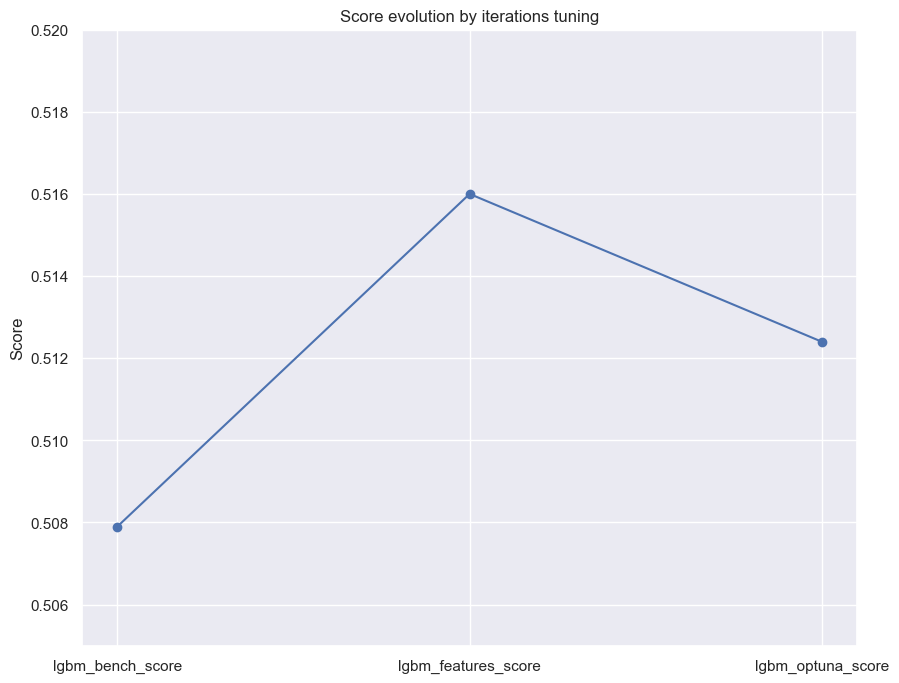

In [129]:
dict_score = {
    "lgbm_bench_score": 0.5079,
    "lgbm_features_score": 0.5160,
    "lgbm_optuna_score": 0.5124,
}


plt.figure(figsize=(10, 8))
plt.plot(list(dict_score.keys()), list(dict_score.values()), marker='o')
plt.ylim(0.505, 0.520)
plt.ylabel("Score")
plt.title("Score evolution by iterations tuning")
plt.show()

##### Prediction distribution vs. True distribution of the '1'

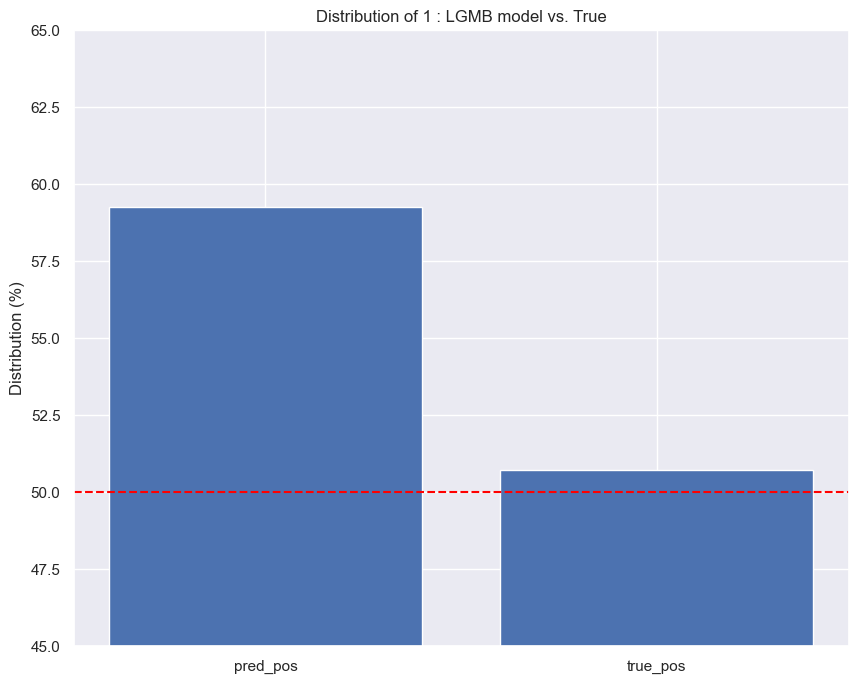

In [132]:
pred_pos = df_avg_predict_bin['prediction'].mean()*100
true_pos = (y_train['target'] > 0).mean()*100

dict_pos={'pred_pos':pred_pos, 'true_pos':true_pos }
plt.figure(figsize=(10, 8))
plt.bar(list(dict_pos.keys()), list(dict_pos.values()))
plt.axhline(50, color='red', linestyle='--')
plt.ylim(45, 65)
plt.ylabel('Distribution (%)')
plt.title("Distribution of 1 : LGMB model vs. True")
plt.show()

np.float64(0.5924066520238469)